<a href="https://colab.research.google.com/github/grullaandrea-png/mushroom_classification_model_dervishi/blob/main/AlexNet_6%2C1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!mkdir -p /content/dataset_locale/
!unzip -q "/content/drive/MyDrive/Deep_learning_project/archive (9).zip" -d "/content/dataset_locale/"

import os
print(os.listdir("/content/dataset_locale/"))

['Data']


In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

data_dir = "/content/dataset_locale/Data"

# 1. Define the trasformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

full_dataset = datasets.ImageFolder(root=data_dir)


# Divide in 70% Train, 10% Validation and 20% Test
total_size = len(full_dataset)
train_size = int(0.70 * total_size)
test_size = int(0.20 * total_size)
val_size = total_size - train_size - test_size

train_raw, test_raw, val_raw = random_split(full_dataset, [train_size, test_size, val_size])

# Class for the application of the trsformations
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# transformation application
train_dataset = ApplyTransform(train_raw, transform=data_transforms['train'])
val_dataset = ApplyTransform(val_raw, transform=data_transforms['val'])
test_dataset = ApplyTransform(test_raw, transform=data_transforms['val'])

# Create the final dataLoader
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training imagines: {len(train_dataset)}")
print(f"Validation imagines: {len(val_dataset)}")
print(f"Test imagines: {len(test_dataset)}")

Training imagines: 8400
Validation imagines: 1200
Test imagines: 2400


In [4]:
import torch
from torch import nn

net = nn.Sequential(
    # 1. Conv
    nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=1),
    nn.BatchNorm2d(96),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    # 2. Conv
    nn.Conv2d(96, 256, kernel_size=5, padding=2),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    # 3, 4, 5 Conv
    nn.Conv2d(256, 384, kernel_size=3, padding=1),
    nn.BatchNorm2d(384),
    nn.ReLU(),

    nn.Conv2d(384, 384, kernel_size=3, padding=1),
    nn.BatchNorm2d(384),
    nn.ReLU(),

    nn.Conv2d(384, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Flatten(),
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 12)
)

In [5]:
# Install the d2l library
!pip install -q d2l==1.0.a1.post0
from d2l import torch as d2l

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 115.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 91.1 MB/s eta 0:00:00


Start the train on cuda...
Epoch [1/50] | Train Loss: 2.7800 | Val Loss: 2.2964 | Val Acc: 20.75%
--> Improvement! Model saving... (Accuracy: 0.00% -> 20.75%)
Epoch [2/50] | Train Loss: 2.3403 | Val Loss: 2.2597 | Val Acc: 22.25%
--> Improvement! Model saving... (Accuracy: 20.75% -> 22.25%)
Epoch [3/50] | Train Loss: 2.2548 | Val Loss: 2.1561 | Val Acc: 28.75%
--> Improvement! Model saving... (Accuracy: 22.25% -> 28.75%)
Epoch [4/50] | Train Loss: 2.1775 | Val Loss: 2.1414 | Val Acc: 28.08%
Epoch [5/50] | Train Loss: 2.1306 | Val Loss: 2.0895 | Val Acc: 30.75%
--> Improvement! Model saving... (Accuracy: 28.75% -> 30.75%)


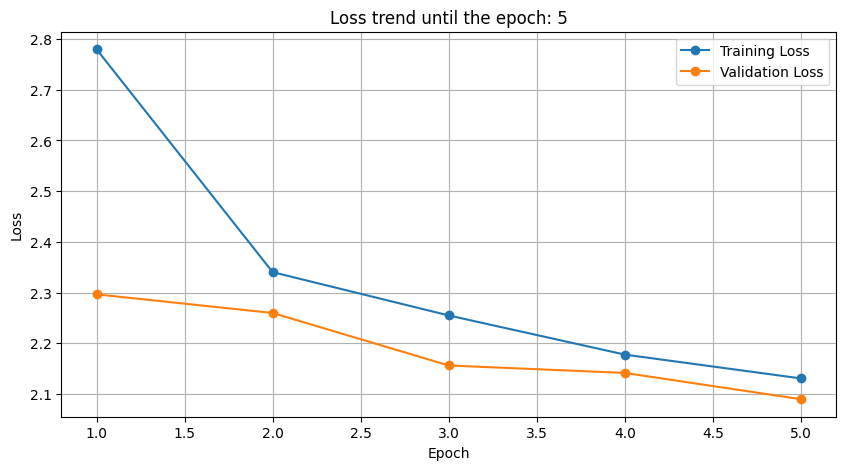

Epoch [6/50] | Train Loss: 2.0813 | Val Loss: 2.0197 | Val Acc: 35.17%
--> Improvement! Model saving... (Accuracy: 30.75% -> 35.17%)
Epoch [7/50] | Train Loss: 2.0361 | Val Loss: 1.9881 | Val Acc: 35.92%
--> Improvement! Model saving... (Accuracy: 35.17% -> 35.92%)
Epoch [8/50] | Train Loss: 2.0004 | Val Loss: 1.9922 | Val Acc: 37.17%
--> Improvement! Model saving... (Accuracy: 35.92% -> 37.17%)
Epoch [9/50] | Train Loss: 1.9719 | Val Loss: 1.9395 | Val Acc: 38.25%
--> Improvement! Model saving... (Accuracy: 37.17% -> 38.25%)
Epoch [10/50] | Train Loss: 1.9297 | Val Loss: 1.8727 | Val Acc: 41.50%
--> Improvement! Model saving... (Accuracy: 38.25% -> 41.50%)


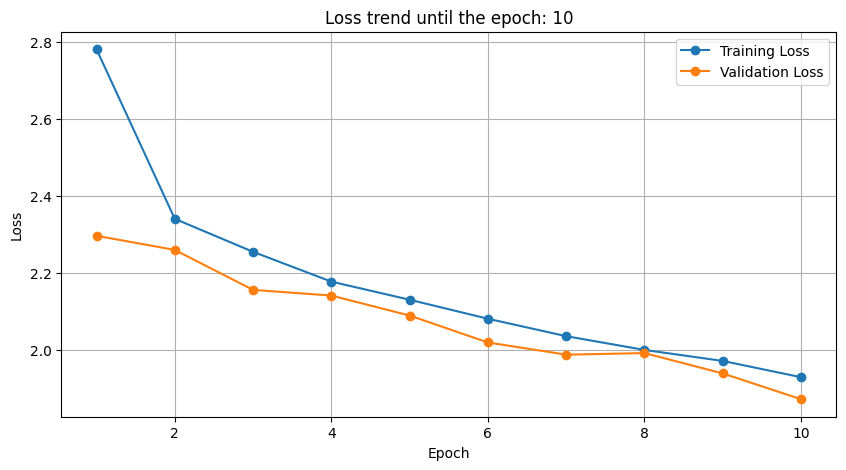

Epoch [11/50] | Train Loss: 1.8955 | Val Loss: 1.8312 | Val Acc: 42.50%
--> Improvement! Model saving... (Accuracy: 41.50% -> 42.50%)
Epoch [12/50] | Train Loss: 1.8604 | Val Loss: 1.8293 | Val Acc: 44.50%
--> Improvement! Model saving... (Accuracy: 42.50% -> 44.50%)
Epoch [13/50] | Train Loss: 1.8258 | Val Loss: 1.8626 | Val Acc: 44.17%
Epoch [14/50] | Train Loss: 1.7884 | Val Loss: 1.7476 | Val Acc: 47.42%
--> Improvement! Model saving... (Accuracy: 44.50% -> 47.42%)
Epoch [15/50] | Train Loss: 1.7518 | Val Loss: 1.7167 | Val Acc: 50.25%
--> Improvement! Model saving... (Accuracy: 47.42% -> 50.25%)


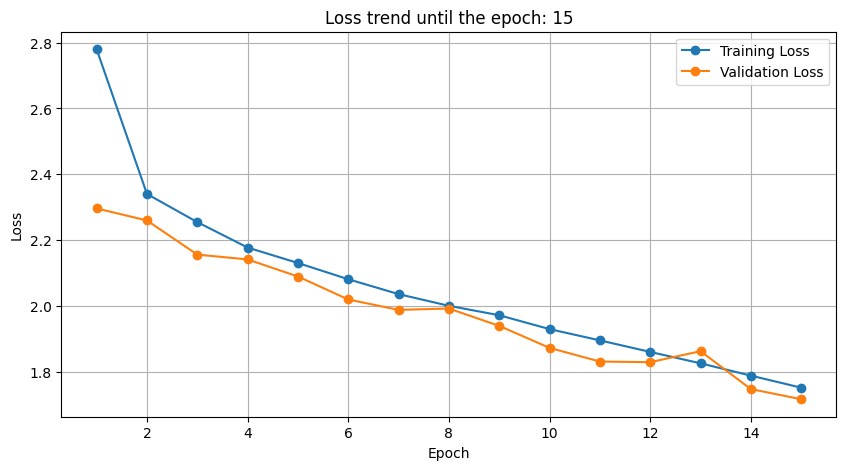

Epoch [16/50] | Train Loss: 1.7179 | Val Loss: 1.7304 | Val Acc: 48.83%
Epoch [17/50] | Train Loss: 1.6826 | Val Loss: 1.6486 | Val Acc: 52.67%
--> Improvement! Model saving... (Accuracy: 50.25% -> 52.67%)
Epoch [18/50] | Train Loss: 1.6379 | Val Loss: 1.6124 | Val Acc: 54.33%
--> Improvement! Model saving... (Accuracy: 52.67% -> 54.33%)
Epoch [19/50] | Train Loss: 1.6011 | Val Loss: 1.5604 | Val Acc: 57.00%
--> Improvement! Model saving... (Accuracy: 54.33% -> 57.00%)
Epoch [20/50] | Train Loss: 1.5531 | Val Loss: 1.5648 | Val Acc: 56.67%


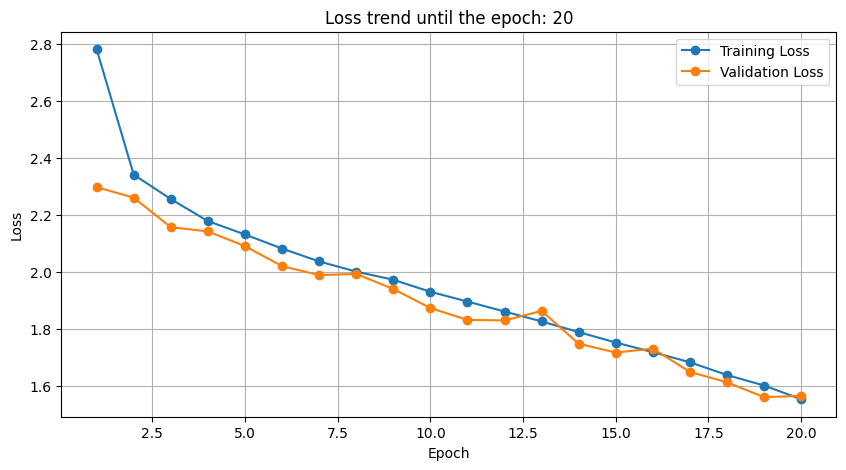

Epoch [21/50] | Train Loss: 1.5183 | Val Loss: 1.5400 | Val Acc: 56.58%
Epoch [22/50] | Train Loss: 1.5013 | Val Loss: 1.4642 | Val Acc: 61.33%
--> Improvement! Model saving... (Accuracy: 57.00% -> 61.33%)
Epoch [23/50] | Train Loss: 1.4570 | Val Loss: 1.4695 | Val Acc: 59.50%
Epoch [24/50] | Train Loss: 1.4149 | Val Loss: 1.4435 | Val Acc: 62.42%
--> Improvement! Model saving... (Accuracy: 61.33% -> 62.42%)
Epoch [25/50] | Train Loss: 1.3812 | Val Loss: 1.4853 | Val Acc: 60.08%


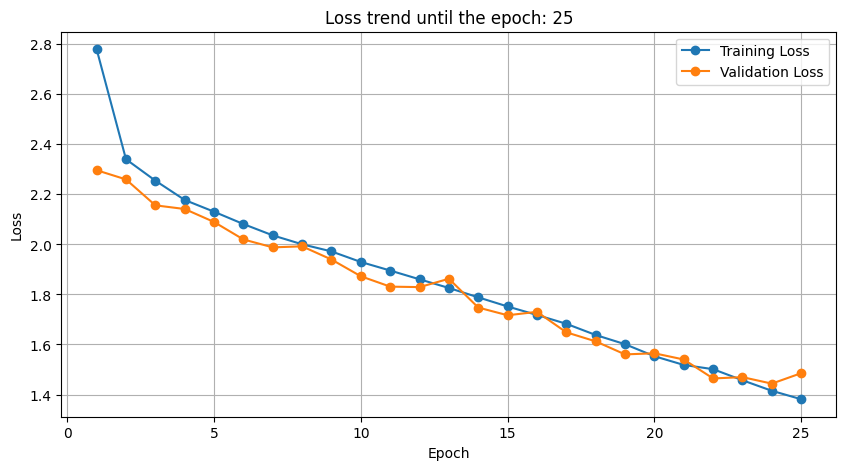

Epoch [26/50] | Train Loss: 1.3528 | Val Loss: 1.3916 | Val Acc: 64.42%
--> Improvement! Model saving... (Accuracy: 62.42% -> 64.42%)
Epoch [27/50] | Train Loss: 1.3039 | Val Loss: 1.4190 | Val Acc: 64.75%
--> Improvement! Model saving... (Accuracy: 64.42% -> 64.75%)
Epoch [28/50] | Train Loss: 1.2685 | Val Loss: 1.3539 | Val Acc: 65.83%
--> Improvement! Model saving... (Accuracy: 64.75% -> 65.83%)
Epoch [29/50] | Train Loss: 1.2451 | Val Loss: 1.3400 | Val Acc: 67.83%
--> Improvement! Model saving... (Accuracy: 65.83% -> 67.83%)
Epoch [30/50] | Train Loss: 1.2166 | Val Loss: 1.3169 | Val Acc: 67.67%


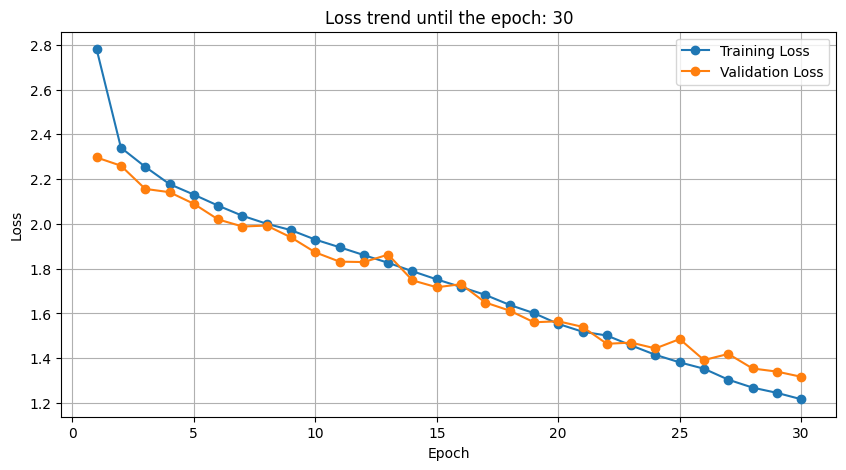

Epoch [31/50] | Train Loss: 1.1877 | Val Loss: 1.2797 | Val Acc: 70.25%
--> Improvement! Model saving... (Accuracy: 67.83% -> 70.25%)
Epoch [32/50] | Train Loss: 1.1674 | Val Loss: 1.2640 | Val Acc: 70.50%
--> Improvement! Model saving... (Accuracy: 70.25% -> 70.50%)
Epoch [33/50] | Train Loss: 1.1343 | Val Loss: 1.2390 | Val Acc: 72.00%
--> Improvement! Model saving... (Accuracy: 70.50% -> 72.00%)
Epoch [34/50] | Train Loss: 1.1036 | Val Loss: 1.2320 | Val Acc: 72.25%
--> Improvement! Model saving... (Accuracy: 72.00% -> 72.25%)
Epoch [35/50] | Train Loss: 1.0906 | Val Loss: 1.2148 | Val Acc: 73.42%
--> Improvement! Model saving... (Accuracy: 72.25% -> 73.42%)


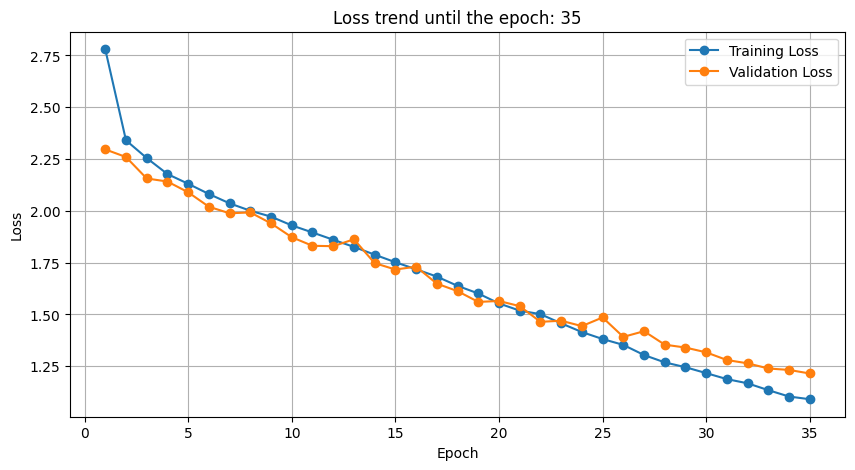

Epoch [36/50] | Train Loss: 1.0798 | Val Loss: 1.2020 | Val Acc: 74.33%
--> Improvement! Model saving... (Accuracy: 73.42% -> 74.33%)
Epoch [37/50] | Train Loss: 1.0433 | Val Loss: 1.2192 | Val Acc: 74.50%
--> Improvement! Model saving... (Accuracy: 74.33% -> 74.50%)
Epoch [38/50] | Train Loss: 1.0315 | Val Loss: 1.2061 | Val Acc: 74.75%
--> Improvement! Model saving... (Accuracy: 74.50% -> 74.75%)
Epoch [39/50] | Train Loss: 1.0323 | Val Loss: 1.1873 | Val Acc: 75.00%
--> Improvement! Model saving... (Accuracy: 74.75% -> 75.00%)
Epoch [40/50] | Train Loss: 1.0066 | Val Loss: 1.1767 | Val Acc: 75.33%
--> Improvement! Model saving... (Accuracy: 75.00% -> 75.33%)


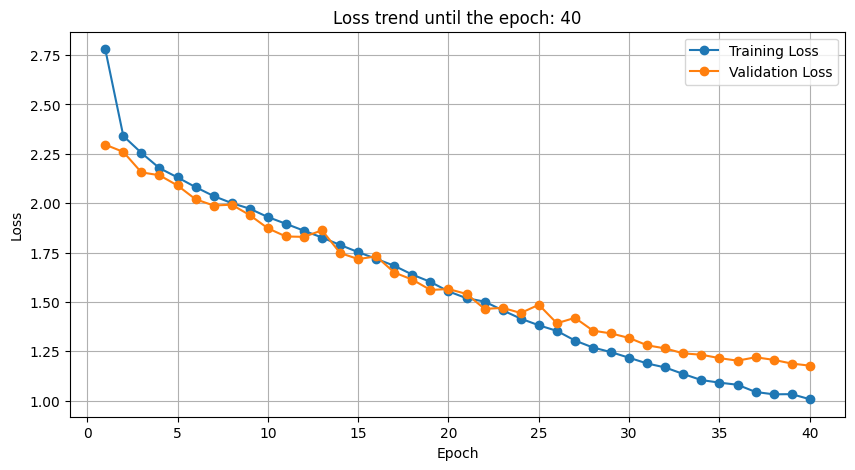

Epoch [41/50] | Train Loss: 0.9976 | Val Loss: 1.1651 | Val Acc: 75.92%
--> Improvement! Model saving... (Accuracy: 75.33% -> 75.92%)
Epoch [42/50] | Train Loss: 0.9934 | Val Loss: 1.1609 | Val Acc: 76.17%
--> Improvement! Model saving... (Accuracy: 75.92% -> 76.17%)
Epoch [43/50] | Train Loss: 0.9733 | Val Loss: 1.1619 | Val Acc: 76.42%
--> Improvement! Model saving... (Accuracy: 76.17% -> 76.42%)
Epoch [44/50] | Train Loss: 0.9740 | Val Loss: 1.1563 | Val Acc: 76.75%
--> Improvement! Model saving... (Accuracy: 76.42% -> 76.75%)
Epoch [45/50] | Train Loss: 0.9563 | Val Loss: 1.1495 | Val Acc: 76.83%
--> Improvement! Model saving... (Accuracy: 76.75% -> 76.83%)


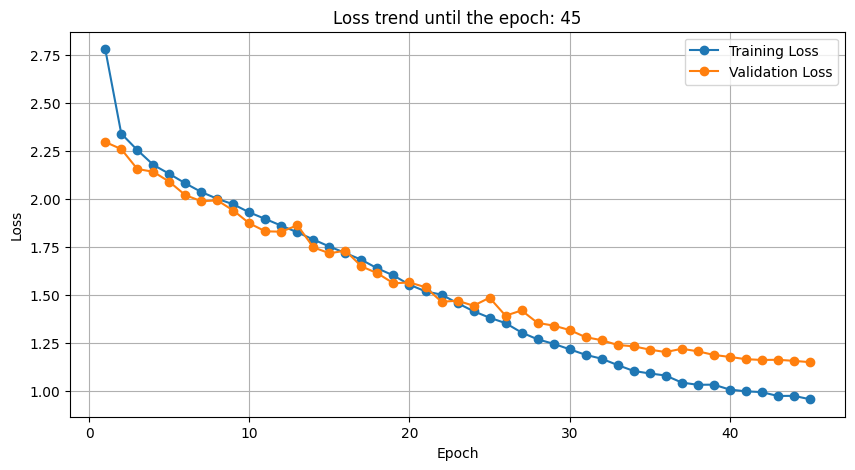

Epoch [46/50] | Train Loss: 0.9523 | Val Loss: 1.1501 | Val Acc: 76.83%
Epoch [47/50] | Train Loss: 0.9505 | Val Loss: 1.1449 | Val Acc: 77.67%
--> Improvement! Model saving... (Accuracy: 76.83% -> 77.67%)
Epoch [48/50] | Train Loss: 0.9505 | Val Loss: 1.1476 | Val Acc: 77.33%
Epoch [49/50] | Train Loss: 0.9444 | Val Loss: 1.1472 | Val Acc: 76.83%
Epoch [50/50] | Train Loss: 0.9549 | Val Loss: 1.1378 | Val Acc: 77.83%
--> Improvement! Model saving... (Accuracy: 77.67% -> 77.83%)


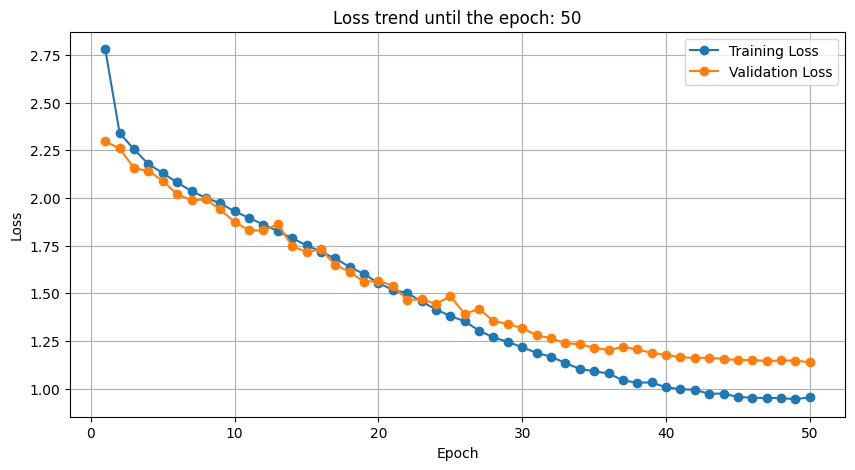

------------------------------
Trained completed! Best accuracy reached: 77.83%


In [6]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import os
import torch.optim as optim
from IPython.display import clear_output

# initial settings
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def init_weights(m):
    if type(m) == nn.Linear or type(m) == nn.Conv2d:
        nn.init.xavier_uniform_(m.weight)
net.apply(init_weights)
net.to(device)

# Parameters
lr = 0.0002
num_epochs = 50

# Optimizer, loss and scheduler
optimizer = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=0.05)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

best_val_acc = 0.0
train_losses = []
val_losses = []

print(f"Start the train on {device}...")

# TRAIN
for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # VALIDATION
    net.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = 100 * correct_val / total_val

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Best model saved
    if val_acc > best_val_acc:
        print(f"--> Improvement! Model saving... (Accuracy: {best_val_acc:.2f}% -> {val_acc:.2f}%)")
        best_val_acc = val_acc

    # Plot
    if (epoch + 1) % 5 == 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, epoch + 2), train_losses, label='Training Loss', marker='o')
        plt.plot(range(1, epoch + 2), val_losses, label='Validation Loss', marker='o')
        plt.title(f'Loss trend until the epoch: {epoch + 1}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

print("-" * 30)
print(f"Trained completed! Best accuracy reached: {best_val_acc:.2f}%")

In [ ]:
save_path = '/content/drive/MyDrive/Deep_learning_project/mushroom_alexnet5.pth'

**Confusion matrix**

>



Prediction computation on the TEST SET...


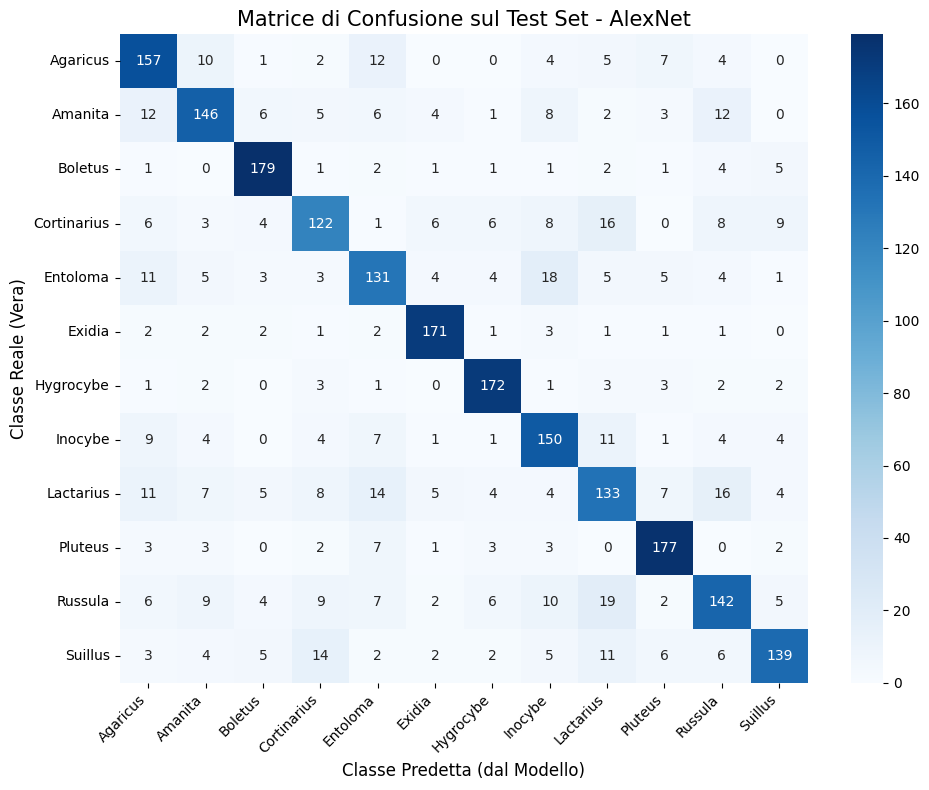

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = []
y_scores = []
y_pred = []

print("Prediction computation on the TEST SET...")

net.eval()

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(d2l.try_gpu())
        outputs = net(X)

        probs = torch.nn.functional.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores)
y_pred = np.array(y_pred)

class_names = full_dataset.classes

# confusion matrix graph
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Classe Predetta (dal Modello)', fontsize=12)
plt.ylabel('Classe Reale (Vera)', fontsize=12)
plt.title('Matrice di Confusione sul Test Set - AlexNet', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**ROC Curve**

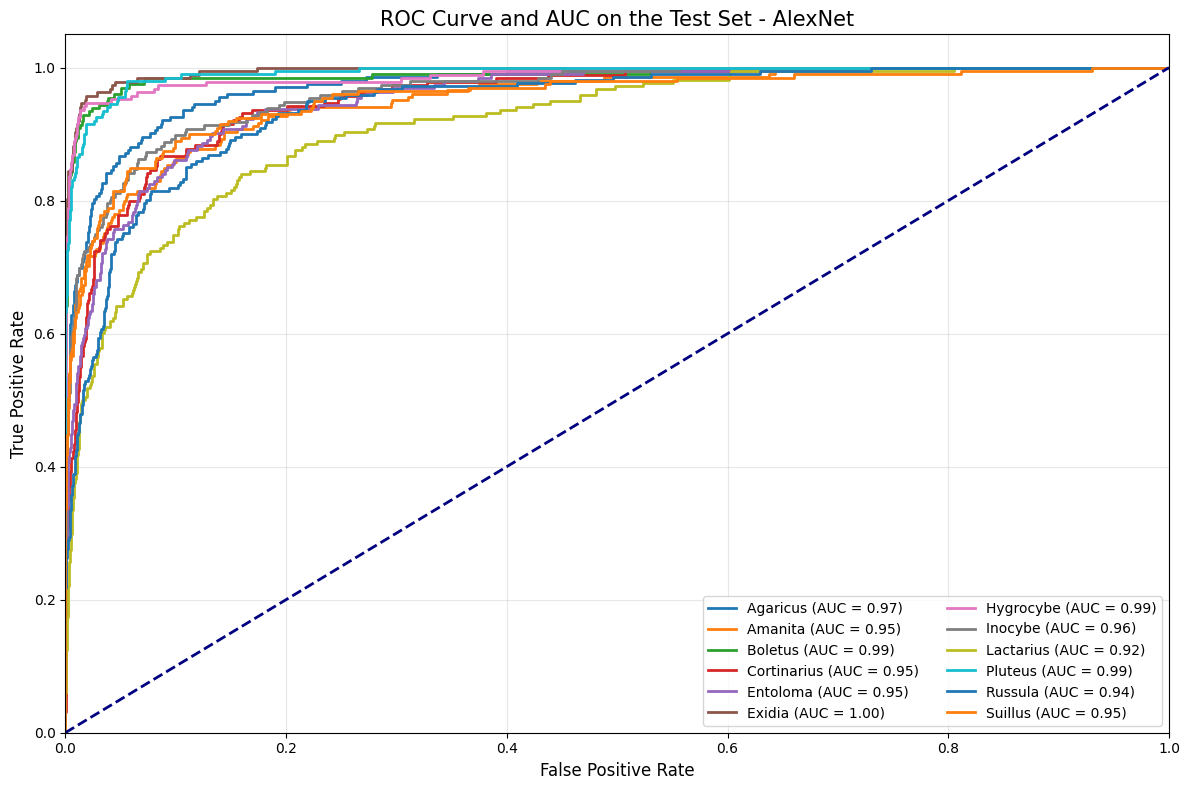

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = len(class_names)

y_true_bin = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(12, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve and AUC on the Test Set - AlexNet', fontsize=15)
plt.legend(loc="lower right", fontsize=10, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()